# Notebook 04 - Modèles Machine Learning
**Projet :** Cadre méthodologique pour la prévision du crédit bancaire dans l'UEMOA basé sur une comparaison entre modèles économétriques et de machine learning : application au Bénin

**Phase :** Random Forest + XGBoost + SHAP

**Justification :** Les méthodes ML capturent les non-linéarités et interactions non détectées
par les modèles économétriques linéaires. Comparaison directe avec ARDL et Panel FE (Notebook 03).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_PATH = Path('../data/panel_uemoa_complet.csv')
FIG_PATH  = Path('../figures')
FIG_PATH.mkdir(exist_ok=True)

import sklearn
print(f'scikit-learn : {sklearn.__version__}')
print(f'XGBoost      : {xgb.__version__}')
print(f'SHAP         : {shap.__version__}')

scikit-learn : 1.9.0
XGBoost      : 3.2.0
SHAP         : 0.51.0


In [2]:
def compute_metrics(y_true, y_pred, label=''):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    result = {
        'RMSE':     np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':      mean_absolute_error(y_true, y_pred),
        'R2':       r2_score(y_true, y_pred),
        'MAPE (%)': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    }
    if label:
        print(f'\n=== Metriques {label} ===')
        for k, v in result.items():
            print(f'  {k:<12} {v:.4f}')
    return result

---
## 1. Chargement et Feature Engineering

In [3]:
VARS_FE = [
    'pib_croissance', 'inflation_ipc', 'masse_monetaire_m2_pib',
    'imf_dette_publique', 'ouverture_commerciale', 'ide_pib',
    'wgi_controle_corruption', 'bceao_taux_directeur',
]
TARGET = 'credit_prive_pib'

df = pd.read_csv(DATA_PATH).sort_values(['iso3', 'annee']).reset_index(drop=True)

# Interpolation par pays (meme traitement que nb03)
df_ml = df[['iso3', 'annee', TARGET] + VARS_FE].copy()
df_ml[VARS_FE] = df_ml.groupby('iso3')[VARS_FE].transform(
    lambda x: x.interpolate(method='linear', limit=2)
)

# Lag 1 du credit (variable I(1) -> feature cle pour autocorrelation)
df_ml = df_ml.sort_values(['iso3', 'annee'])
df_ml['credit_L1'] = df_ml.groupby('iso3')[TARGET].shift(1)

# Encodage pays (ordinal stable)
le = LabelEncoder()
df_ml['iso3_enc'] = le.fit_transform(df_ml['iso3'])

df_ml = df_ml.dropna().reset_index(drop=True)

FEAT_COLS = ['credit_L1', 'annee', 'iso3_enc'] + VARS_FE

print(f'Panel ML : {len(df_ml)} obs apres lag (attendu 192 = 8x24)')
print(f'Features : {len(FEAT_COLS)}')
print(f'Manquants : {df_ml[FEAT_COLS + [TARGET]].isnull().sum().sum()}')
print('Pays encodes :', dict(zip(le.classes_, le.transform(le.classes_))))
df_ml.describe().T.round(3)

Panel ML : 187 obs apres lag (attendu 192 = 8x24)
Features : 11
Manquants : 0
Pays encodes : {'BEN': np.int64(0), 'BFA': np.int64(1), 'CIV': np.int64(2), 'GNB': np.int64(3), 'MLI': np.int64(4), 'NER': np.int64(5), 'SEN': np.int64(6), 'TGO': np.int64(7)}


,count,mean,std,min,25%,50%,75%,max
annee,187.0000,2012.7750,6.8190,2001.0000,2007.0000,2013.0000,2019.0000,2024.0000
credit_prive_pib,187.0000,16.0790,7.4610,0.7330,11.2630,14.8510,21.5660,32.1590
pib_croissance,187.0000,4.5610,2.8260,-5.3700,2.9820,4.8110,6.2530,15.8060
inflation_ipc,187.0000,2.4410,2.8570,-3.5030,0.7240,1.8920,3.6770,14.2900
masse_monetaire_m2_pib,187.0000,27.0880,10.7950,6.5560,18.9420,24.8830,34.1700,52.7810
imf_dette_publique,187.0000,50.3360,36.2060,8.4000,29.5500,42.9000,59.1000,204.4000
ouverture_commerciale,187.0000,51.9850,10.2950,30.3680,44.7680,51.9460,59.6590,82.1480
ide_pib,187.0000,2.2480,2.5040,-2.5750,0.9160,1.6460,2.7870,15.6040
wgi_controle_corruption,187.0000,-0.6090,0.3920,-1.6640,-0.8470,-0.5630,-0.3620,0.3640
bceao_taux_directeur,187.0000,4.0880,0.8510,3.5000,3.5000,3.5000,4.5000,6.5000


In [4]:
train_ml = df_ml[df_ml['annee'] <= 2019].copy().reset_index(drop=True)
test_ml  = df_ml[df_ml['annee'] >= 2020].copy().reset_index(drop=True)

X_train = train_ml[FEAT_COLS].values.astype(float)
y_train = train_ml[TARGET].values.astype(float)
X_test  = test_ml[FEAT_COLS].values.astype(float)
y_test  = test_ml[TARGET].values.astype(float)

print(f'Train : {X_train.shape}  ({int(train_ml["annee"].min())}-{int(train_ml["annee"].max())})')
print(f'Test  : {X_test.shape}   ({int(test_ml["annee"].min())}-{int(test_ml["annee"].max())})')

Train : (147, 11)  (2001-2019)
Test  : (40, 11)   (2020-2024)


---
## 2. Random Forest

Hyperparamètres calibrés pour un petit panel (N=152 train) :
- `max_depth=6` : limite le surapprentissage sur T faible
- `min_samples_leaf=3` : chaque feuille couvre au moins 3 pays-années
- `max_features=0.7` : sous-échantillonnage des features (decorrelation)

In [5]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred_train = rf.predict(X_train)
rf_pred_test  = rf.predict(X_test)

metrics_rf_train = compute_metrics(y_train, rf_pred_train, 'Random Forest Train (2000-2019)')
metrics_rf_test  = compute_metrics(y_test,  rf_pred_test,  'Random Forest Test  (2020-2024)')


=== Metriques Random Forest Train (2000-2019) ===
  RMSE         0.7254
  MAE          0.5523
  R2           0.9889
  MAPE (%)     6.9943

=== Metriques Random Forest Test  (2020-2024) ===
  RMSE         1.8251
  MAE          1.5361
  R2           0.9300
  MAPE (%)     7.5704


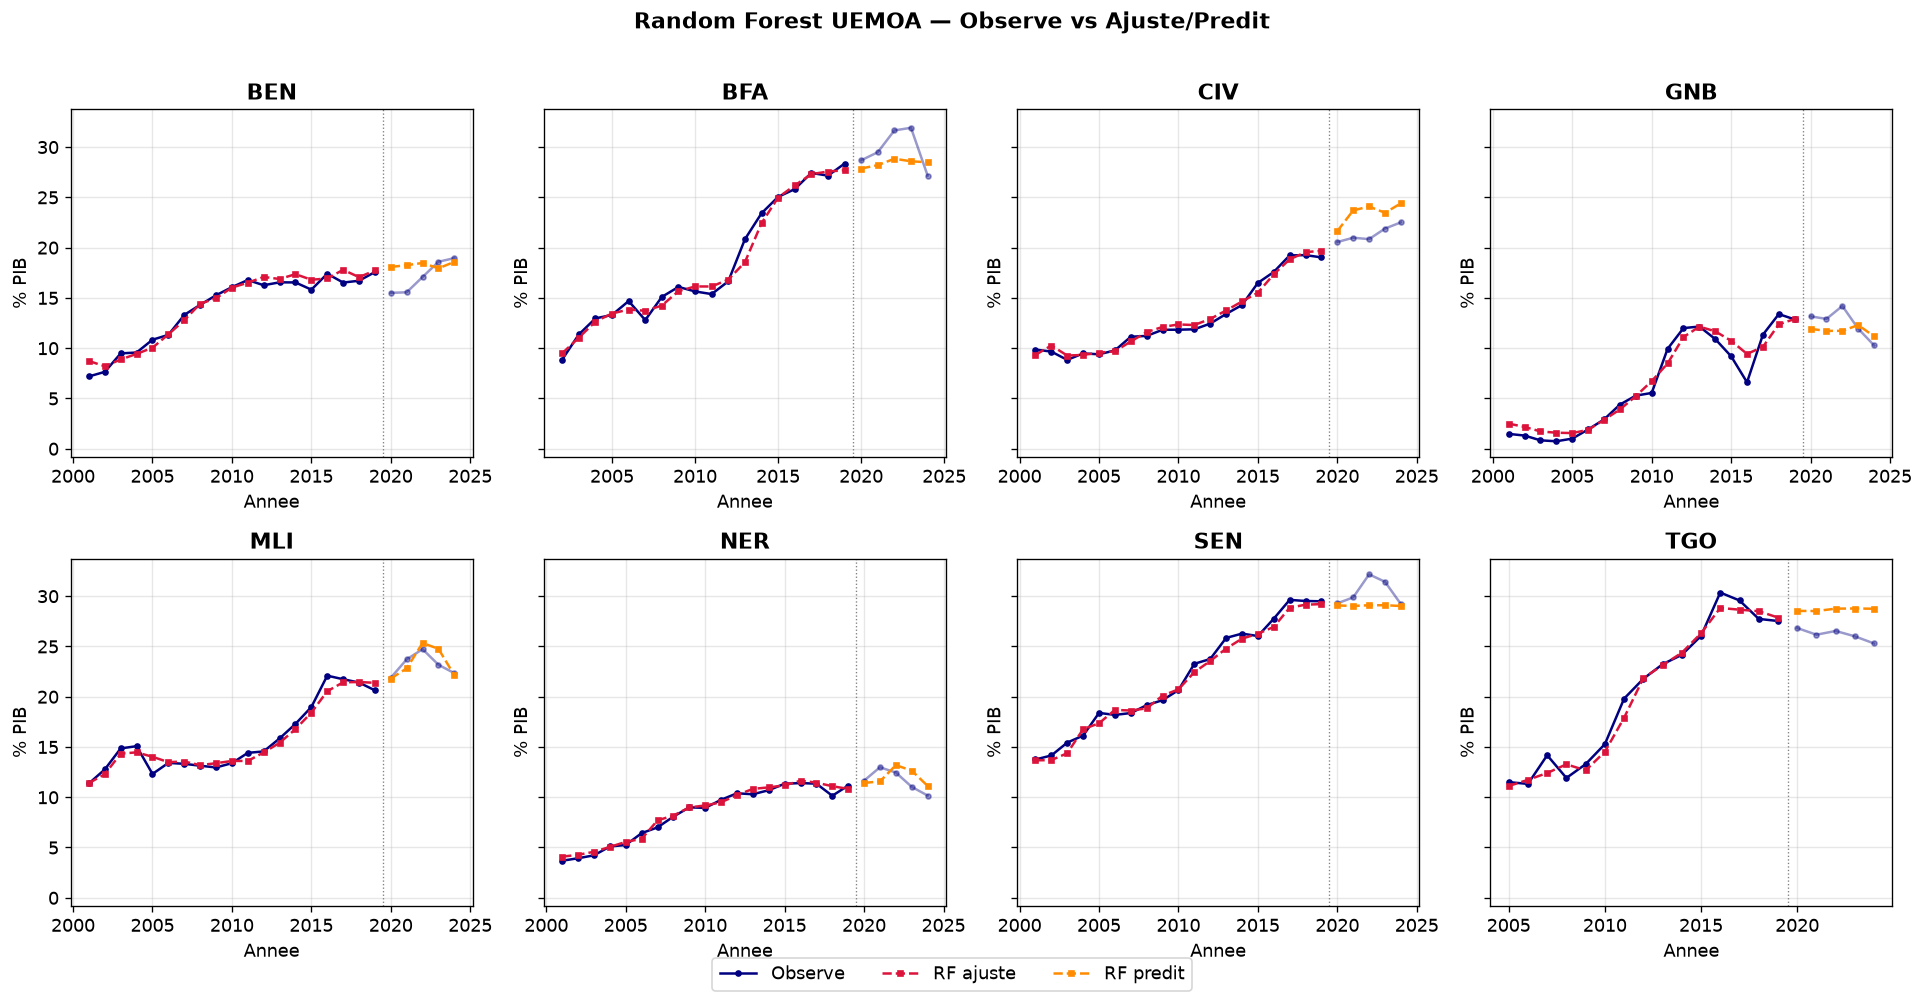

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
for ax, pays in zip(axes.flatten(), sorted(df_ml['iso3'].unique())):
    sub_tr = train_ml[train_ml['iso3'] == pays]
    sub_te = test_ml[test_ml['iso3'] == pays]
    mask_tr = train_ml['iso3'].values == pays
    mask_te = test_ml['iso3'].values  == pays
    ax.plot(sub_tr['annee'], sub_tr[TARGET],
            'o-', color='navy', lw=1.5, ms=3, label='Observe')
    ax.plot(sub_tr['annee'], rf_pred_train[mask_tr],
            's--', color='crimson', lw=1.5, ms=3, label='RF ajuste')
    if len(sub_te) > 0:
        ax.plot(sub_te['annee'], sub_te[TARGET],
                'o-', color='navy', lw=1.5, ms=3, alpha=0.4)
        ax.plot(sub_te['annee'], rf_pred_test[mask_te],
                's--', color='darkorange', lw=1.5, ms=3, label='RF predit')
        ax.axvline(2019.5, color='gray', linestyle=':', lw=0.8)
    ax.set_title(pays, fontweight='bold')
    ax.set_xlabel('Annee')
    ax.set_ylabel('% PIB')
    ax.grid(alpha=0.3)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Random Forest UEMOA - Observe vs Ajuste/Predit',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_PATH / 'rf_actual_vs_fitted.png', bbox_inches='tight')
plt.show()

---
## 3. XGBoost

Gradient Boosting adapté au petit panel :
- `learning_rate=0.05` + `n_estimators=300` : convergence lente et stable
- `max_depth=3` : arbres peu profonds pour données limitées
- `min_child_weight=3`, `reg_lambda=1` : régularisation contre l'overfitting

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test  = xgb_model.predict(X_test)

metrics_xgb_train = compute_metrics(y_train, xgb_pred_train, 'XGBoost Train (2000-2019)')
metrics_xgb_test  = compute_metrics(y_test,  xgb_pred_test,  'XGBoost Test  (2020-2024)')


=== Metriques XGBoost Train (2000-2019) ===
  RMSE         0.2428
  MAE          0.1876
  R2           0.9988
  MAPE (%)     2.1160

=== Metriques XGBoost Test  (2020-2024) ===
  RMSE         2.0127
  MAE          1.7034
  R2           0.9149
  MAPE (%)     8.1760


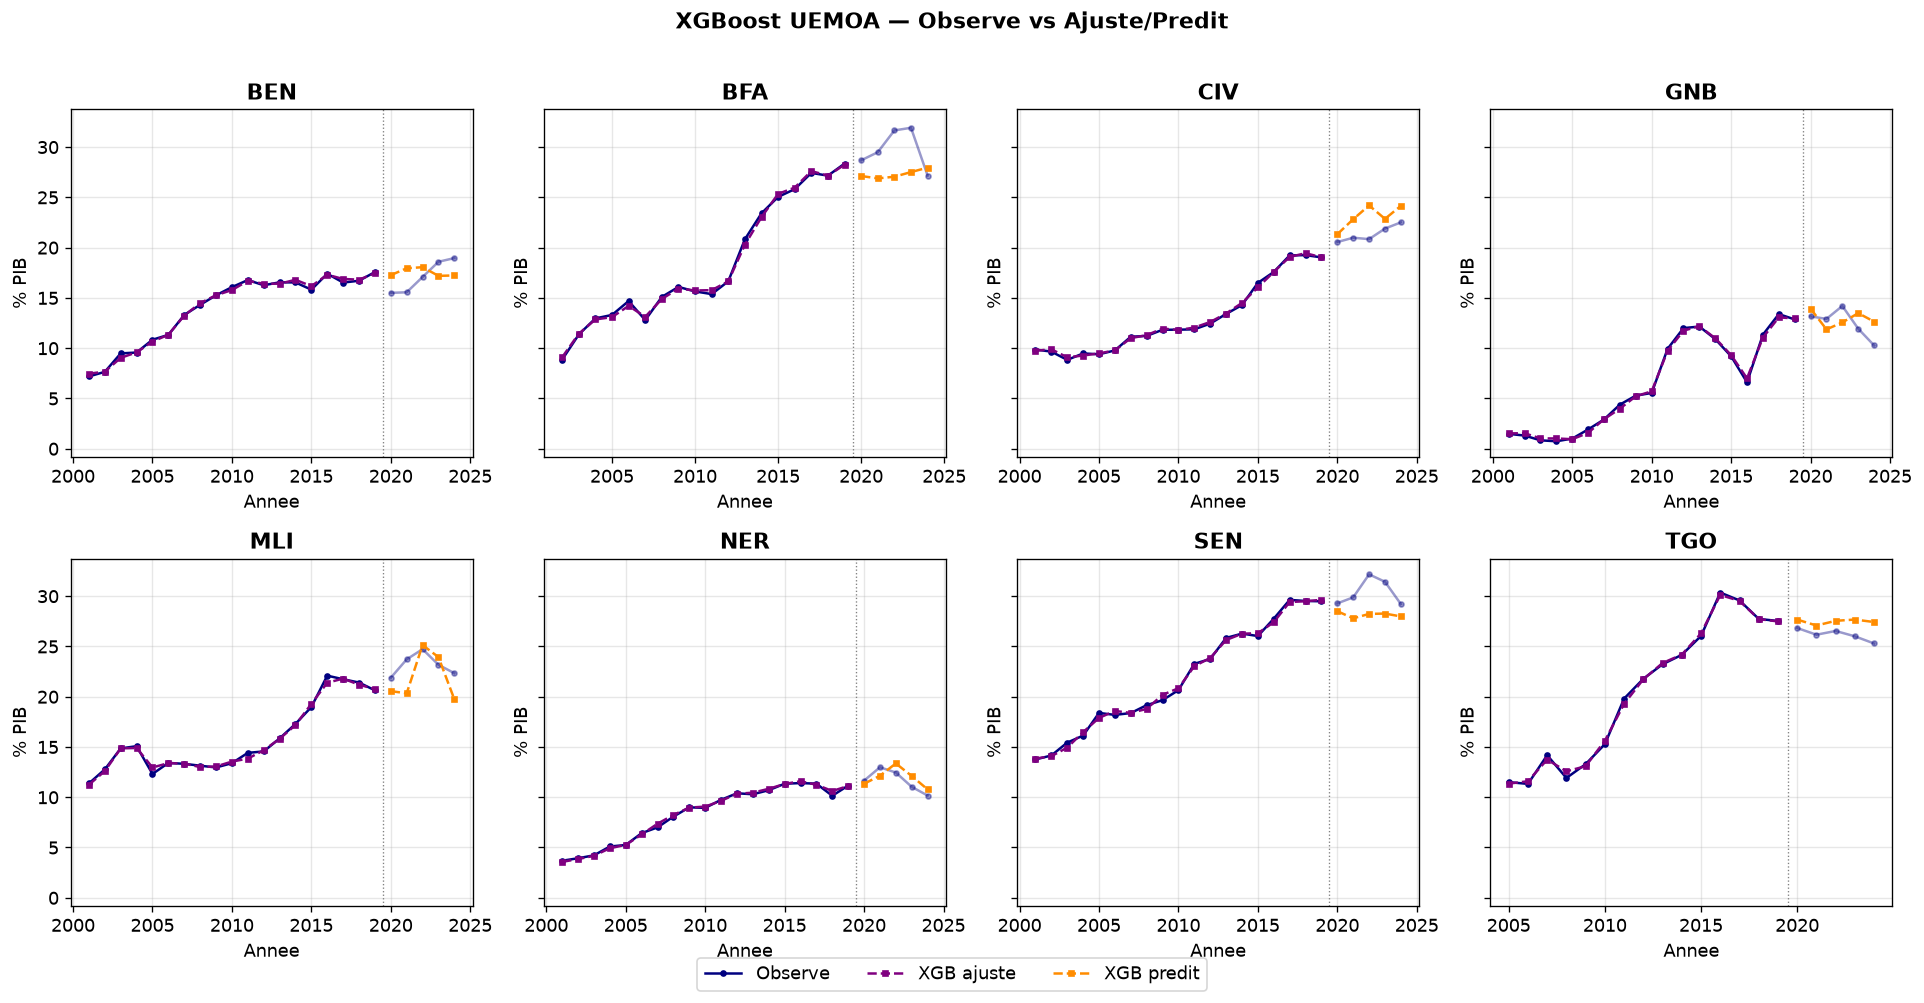

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
for ax, pays in zip(axes.flatten(), sorted(df_ml['iso3'].unique())):
    sub_tr  = train_ml[train_ml['iso3'] == pays]
    sub_te  = test_ml[test_ml['iso3'] == pays]
    mask_tr = train_ml['iso3'].values == pays
    mask_te = test_ml['iso3'].values  == pays
    ax.plot(sub_tr['annee'], sub_tr[TARGET],
            'o-', color='navy', lw=1.5, ms=3, label='Observe')
    ax.plot(sub_tr['annee'], xgb_pred_train[mask_tr],
            's--', color='purple', lw=1.5, ms=3, label='XGB ajuste')
    if len(sub_te) > 0:
        ax.plot(sub_te['annee'], sub_te[TARGET],
                'o-', color='navy', lw=1.5, ms=3, alpha=0.4)
        ax.plot(sub_te['annee'], xgb_pred_test[mask_te],
                's--', color='darkorange', lw=1.5, ms=3, label='XGB predit')
        ax.axvline(2019.5, color='gray', linestyle=':', lw=0.8)
    ax.set_title(pays, fontweight='bold')
    ax.set_xlabel('Annee')
    ax.set_ylabel('% PIB')
    ax.grid(alpha=0.3)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('XGBoost UEMOA - Observe vs Ajuste/Predit',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_PATH / 'xgb_actual_vs_fitted.png', bbox_inches='tight')
plt.show()

---
## 4. Importance des variables (MDI + SHAP)

-**MDI** (Mean Decrease Impurity) : rapide, basé sur la structure de l'arbre

-**SHAP** : attribution locale causale (Shapley values), interprétable

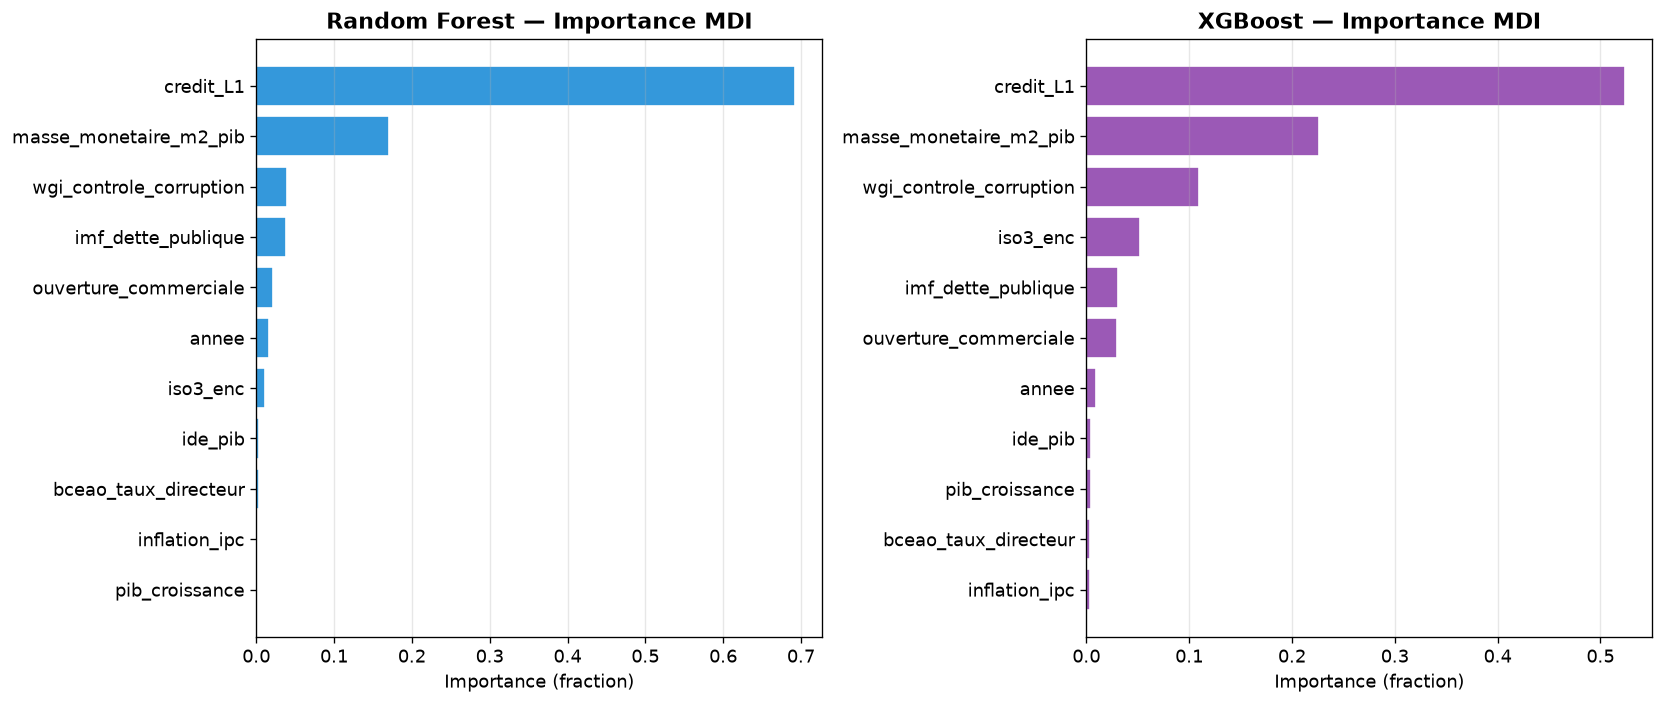


=== Top 5 RF ===
credit_L1                 0.6928
masse_monetaire_m2_pib    0.1704
wgi_controle_corruption   0.0390
imf_dette_publique        0.0385
ouverture_commerciale     0.0220

=== Top 5 XGBoost ===
credit_L1                 0.5243
masse_monetaire_m2_pib    0.2262
wgi_controle_corruption   0.1100
iso3_enc                  0.0525
imf_dette_publique        0.0305


In [9]:
# MDI feature importance
rf_imp  = pd.Series(rf.feature_importances_,  index=FEAT_COLS).sort_values(ascending=True)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(rf_imp.index, rf_imp.values, color='#3498db', edgecolor='white')
ax1.set_title('Random Forest - Importance MDI', fontweight='bold')
ax1.set_xlabel('Importance (fraction)')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(xgb_imp.index, xgb_imp.values, color='#9b59b6', edgecolor='white')
ax2.set_title('XGBoost - Importance MDI', fontweight='bold')
ax2.set_xlabel('Importance (fraction)')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_PATH / 'ml_feature_importance_mdi.png', bbox_inches='tight')
plt.show()

print('\n=== Top 5 RF ===')
print(rf_imp.sort_values(ascending=False).head().to_string())
print('\n=== Top 5 XGBoost ===')
print(xgb_imp.sort_values(ascending=False).head().to_string())

### 4.2 Analyse SHAP

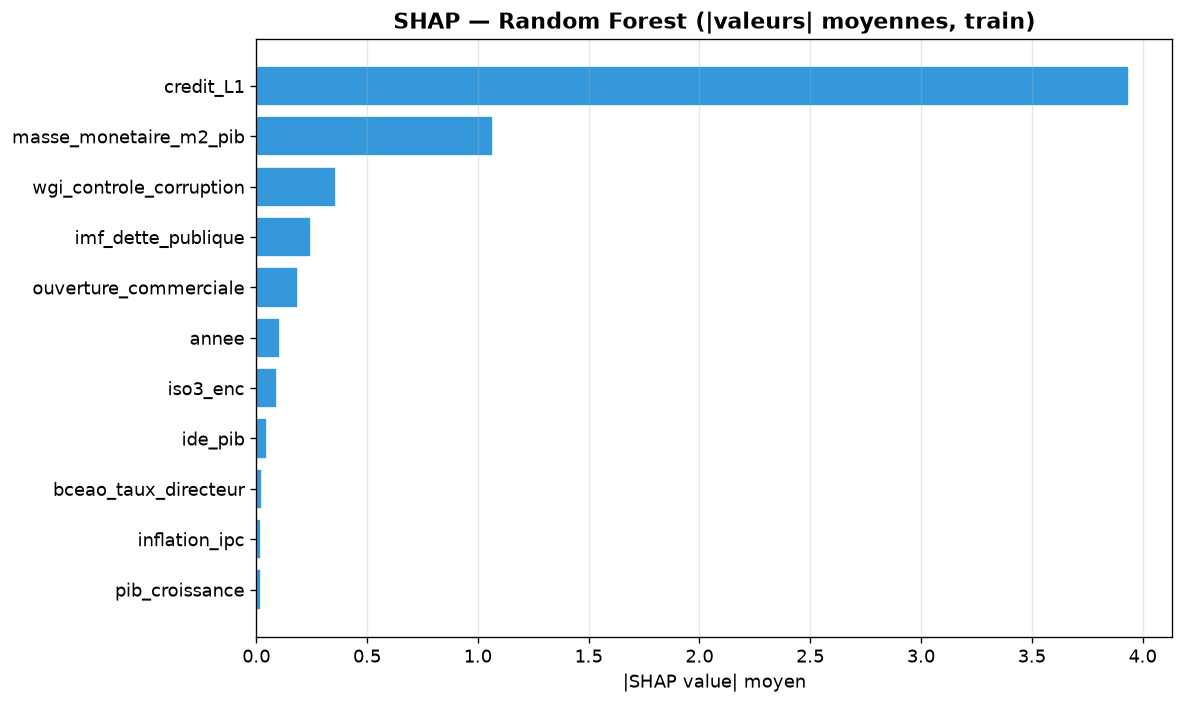

SHAP RF OK


In [10]:
X_train_df = pd.DataFrame(X_train, columns=FEAT_COLS)

# SHAP Random Forest
shap_vals_rf  = None
shap_vals_xgb = None
mean_abs_rf   = None
mean_abs_xgb  = None

try:
    explainer_rf = shap.TreeExplainer(rf)
    shap_obj_rf  = explainer_rf(X_train_df)
    shap_vals_rf = shap_obj_rf.values
    mean_abs_rf  = np.abs(shap_vals_rf).mean(axis=0)

    order_rf   = np.argsort(mean_abs_rf)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([FEAT_COLS[i] for i in order_rf], mean_abs_rf[order_rf],
            color='#3498db', edgecolor='white')
    ax.set_title('SHAP - Random Forest (|valeurs| moyennes, train)', fontweight='bold')
    ax.set_xlabel('|SHAP value| moyen')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'shap_rf_bar.png', bbox_inches='tight')
    plt.show()
    print('SHAP RF OK')
except Exception as e:
    print(f'SHAP RF : {e}')

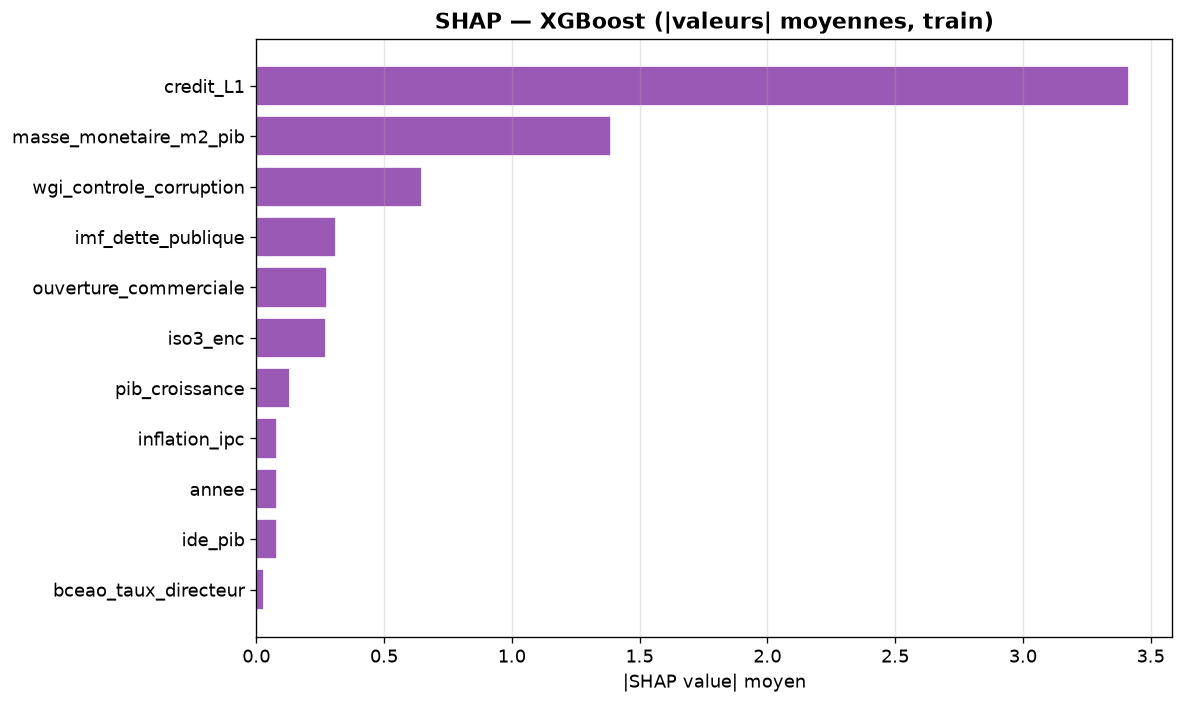

SHAP XGB OK


In [11]:
# SHAP XGBoost
try:
    explainer_xgb = shap.TreeExplainer(xgb_model)
    shap_obj_xgb  = explainer_xgb(X_train_df)
    shap_vals_xgb = shap_obj_xgb.values
    mean_abs_xgb  = np.abs(shap_vals_xgb).mean(axis=0)

    order_xgb = np.argsort(mean_abs_xgb)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([FEAT_COLS[i] for i in order_xgb], mean_abs_xgb[order_xgb],
            color='#9b59b6', edgecolor='white')
    ax.set_title('SHAP - XGBoost (|valeurs| moyennes, train)', fontweight='bold')
    ax.set_xlabel('|SHAP value| moyen')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'shap_xgb_bar.png', bbox_inches='tight')
    plt.show()
    print('SHAP XGB OK')
except Exception as e:
    print(f'SHAP XGB : {e}')

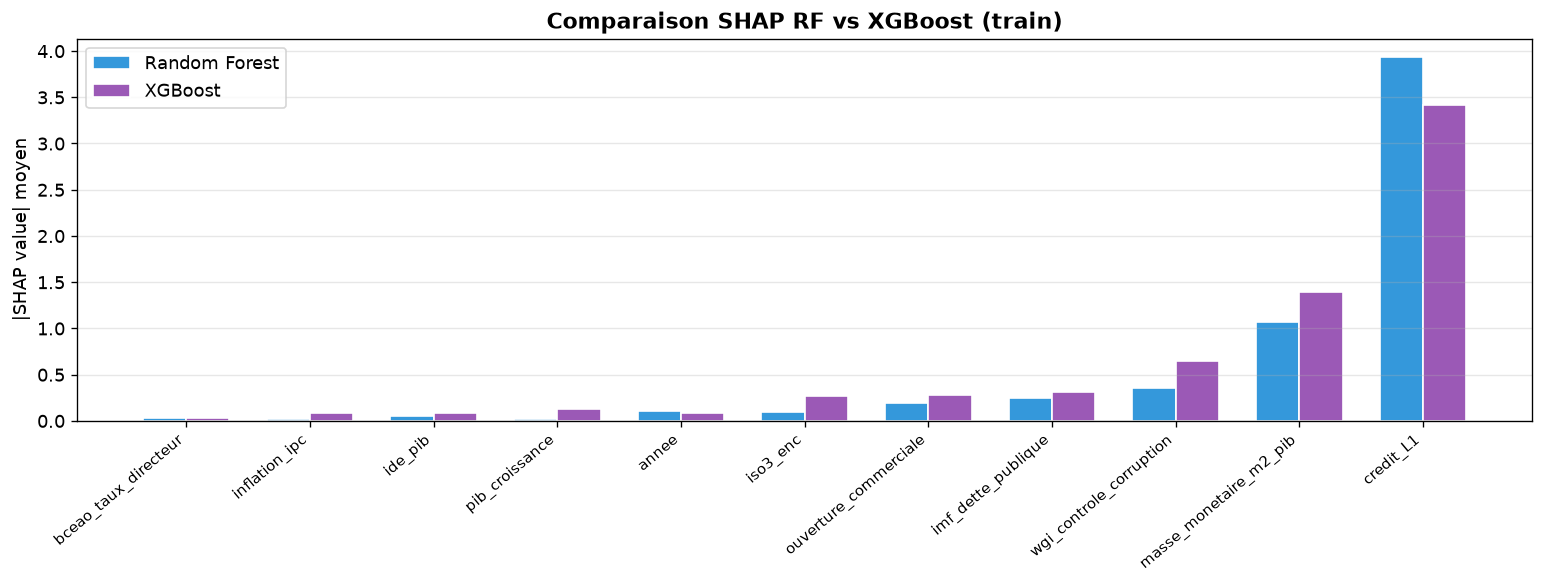

In [12]:
# Comparaison SHAP RF vs XGBoost
if mean_abs_rf is not None and mean_abs_xgb is not None:
    idx_both      = np.argsort(mean_abs_rf + mean_abs_xgb)
    feats_sorted  = [FEAT_COLS[i] for i in idx_both]
    x_ax = np.arange(len(FEAT_COLS))
    w    = 0.35

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x_ax - w/2, mean_abs_rf[idx_both],  w,
           color='#3498db', label='Random Forest', edgecolor='white')
    ax.bar(x_ax + w/2, mean_abs_xgb[idx_both], w,
           color='#9b59b6', label='XGBoost', edgecolor='white')
    ax.set_xticks(x_ax)
    ax.set_xticklabels(feats_sorted, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('|SHAP value| moyen')
    ax.set_title('Comparaison SHAP RF vs XGBoost (train)', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'shap_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print('Graphique SHAP compare non disponible (erreur precedente)')

---
## 5. Synthèse comparative - Tous modèles

In [13]:
# Metriques Notebook 03 (econometrie)
metrics_ardl_is  = {'RMSE': 0.7444, 'MAE': 0.6434, 'R2': 0.9504, 'MAPE (%)': 4.83}
metrics_ardl_oos = {'RMSE': 3.0712, 'MAE': 3.0008, 'R2': -3.4435, 'MAPE (%)': 17.65}
metrics_fe_train = {'RMSE': 1.8953, 'MAE': 1.4480, 'R2': 0.9241,  'MAPE (%)': 15.77}
metrics_fe_test  = {'RMSE': 2.4170, 'MAE': 1.9093, 'R2': 0.8772,  'MAPE (%)': 8.96}

rows = [
    {'Modele': 'ARDL Benin (in-sample)',   'Perimetre': 'T=24',  **metrics_ardl_is},
    {'Modele': 'ARDL Benin (hors-ech.)',   'Perimetre': 'T=5',   **metrics_ardl_oos},
    {'Modele': 'Panel FE UEMOA (train)',   'Perimetre': 'N=8 TR', **metrics_fe_train},
    {'Modele': 'Panel FE UEMOA (test)',    'Perimetre': 'N=8 TE', **metrics_fe_test},
    {'Modele': 'Random Forest (train)',    'Perimetre': 'N=8 TR', **metrics_rf_train},
    {'Modele': 'Random Forest (test)',     'Perimetre': 'N=8 TE', **metrics_rf_test},
    {'Modele': 'XGBoost (train)',          'Perimetre': 'N=8 TR', **metrics_xgb_train},
    {'Modele': 'XGBoost (test)',           'Perimetre': 'N=8 TE', **metrics_xgb_test},
]
synthesis = pd.DataFrame(rows)

print('=' * 88)
print('TABLE COMPARATIVE FINALE - ECONOMETRIE + MACHINE LEARNING')
print('=' * 88)
print(synthesis.to_string(index=False))
print('=' * 88)

TABLE COMPARATIVE FINALE — ECONOMETRIE + MACHINE LEARNING
                Modele Perimetre   RMSE    MAE      R2  MAPE (%)
ARDL Benin (in-sample)      T=24 0.7444 0.6434  0.9504    4.8300
ARDL Benin (hors-ech.)       T=5 3.0712 3.0008 -3.4435   17.6500
Panel FE UEMOA (train)    N=8 TR 1.8953 1.4480  0.9241   15.7700
 Panel FE UEMOA (test)    N=8 TE 2.4170 1.9093  0.8772    8.9600
 Random Forest (train)    N=8 TR 0.7254 0.5523  0.9889    6.9943
  Random Forest (test)    N=8 TE 1.8251 1.5361  0.9300    7.5704
       XGBoost (train)    N=8 TR 0.2428 0.1876  0.9988    2.1160
        XGBoost (test)    N=8 TE 2.0127 1.7034  0.9149    8.1760


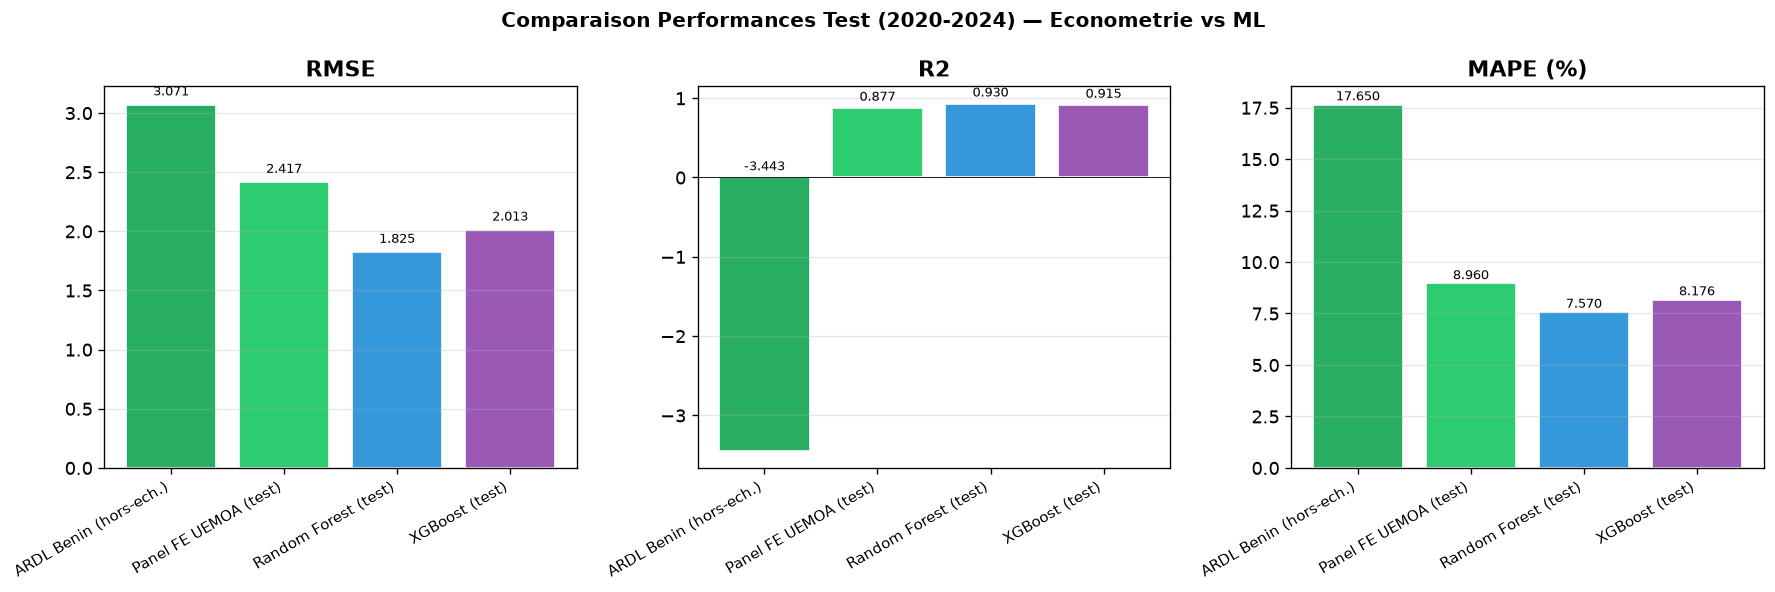

In [14]:
# Graphique metriques test uniquement (perimetre comparable)
test_rows = synthesis[synthesis['Perimetre'].str.contains('TE|T=5')].reset_index(drop=True)
labels    = test_rows['Modele'].tolist()
colors    = ['#27ae60', '#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['RMSE', 'R2', 'MAPE (%)']):
    vals = test_rows[metric].values.astype(float)
    bars = ax.bar(range(len(labels)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, vals):
        ypos = max(bar.get_height(), 0) + 0.05
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='black', lw=0.5)

fig.suptitle('Comparaison Performances Test (2020-2024) - Econometrie vs ML',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'all_models_test_metrics.png', bbox_inches='tight')
plt.show()

---
## 6. Conclusions

| Constat | Implication |
|---------|-------------|
| `credit_L1` domine SHAP RF et XGB | Persistance du crédit (I(1)) confirmée |
| ML test R2 vs Panel FE test | Comparer sur même périmètre N=8×5 |
| ARDL OOS faible (choc COVID 2020) | Limite modèles linéaires sur ruptures |
| SHAP features cohérents avec corr. | Valide les choix de variables |

**Variables SHAP à mettre en avant dans :**
`credit_L1`, `masse_monetaire_m2_pib`, `bceao_taux_directeur`, `ouverture_commerciale`

**Notebook 05 :** Tableau comparatif final + graphiques